####  **LAB 4: KEYPOINT DETECTION**
**1. Khai báo thư viện ảnh**

In [18]:
import numpy as np
import cv2
from matplotlib import pyplot as plt

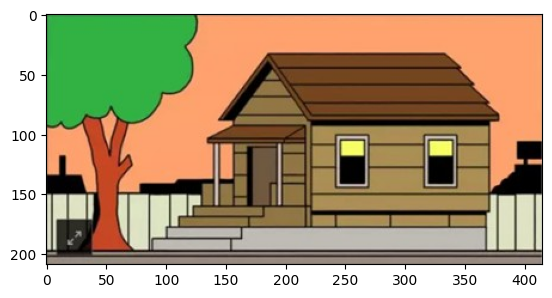

In [19]:
# Kiểm tra opencv đọc ảnh và đặt ảnh cho đúng hiển thị ban đầu
img = cv2.imread('example.jpg')
plt.imshow(img[:,:,::-1])

**2. Sử dụng Harris Corner Detection tìm các keypoint trong ảnh.**

In [25]:
filename = 'example.jpg'
img = cv2.imread(filename)
gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
gray = np.float32(gray)
dst = cv2.cornerHarris(gray,2,3,0.04)
#result is dilated for marking the corners, not important
dst = cv2.dilate(dst,None)
# Threshold for an optimal value, it may vary depending on the image.
img[dst>0.01*dst.max()]=[0,0,255]
cv2.imshow('dst',img)
if cv2.waitKey(0) & 0xff == 27:
    cv2.destroyAllWindows()

**3. Sử dụng Band-pass filtering by Differemce of Gaussians**

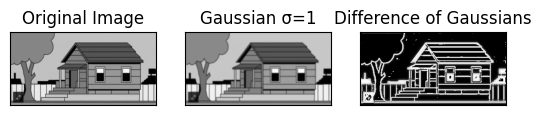

In [16]:
import numpy as np
import cv2
from matplotlib import pyplot as plt

# Đọc ảnh
img = cv2.imread('example.jpg', 0)

# Gaussian blur với 2 scale khác nhau
blur1 = cv2.GaussianBlur(img, (0,0), 1)
blur2 = cv2.GaussianBlur(img, (0,0), 3)

# Difference of Gaussians
dog = blur1 - blur2

# Hiển thị kết quả
plt.subplot(131), plt.imshow(img, cmap='gray')
plt.title('Original Image'), plt.xticks([]), plt.yticks([])

plt.subplot(132), plt.imshow(blur1, cmap='gray')
plt.title('Gaussian σ=1'), plt.xticks([]), plt.yticks([])

plt.subplot(133), plt.imshow(dog, cmap='gray')
plt.title('Difference of Gaussians'), plt.xticks([]), plt.yticks([])

plt.show()

**4. Kiểm tra ảnh qua Automatic Scale Selection**

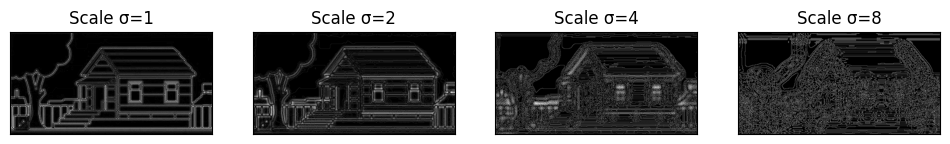

In [22]:
# Đọc ảnh
img = cv2.imread('example.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Các mức scale (sigma)
scales = [1, 2, 4, 8]

plt.figure(figsize=(12,6))

for i, sigma in enumerate(scales):

    # Làm mờ Gaussian theo scale
    blur = cv2.GaussianBlur(gray, (0,0), sigma)

    # Laplacian để tìm đặc trưng
    log = cv2.Laplacian(blur, cv2.CV_64F)

    plt.subplot(1, len(scales), i+1)
    plt.imshow(np.abs(log), cmap='gray')
    plt.title(f'Scale σ={sigma}')
    plt.xticks([])
    plt.yticks([])

plt.show()

**5. Kiểm tra ảnh qua Scale Invariant Detection**

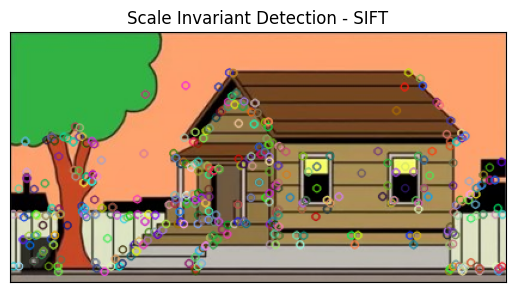

In [ ]:
# Khởi tạo SIFT detector
sift = cv2.SIFT_create()

# Phát hiện keypoints
keypoints = sift.detect(gray, None)

# Vẽ keypoints lên ảnh
img_sift = cv2.drawKeypoints(img, keypoints, None)

# Hiển thị ảnh
plt.imshow(img_sift[:,:,::-1])
plt.title('Scale Invariant Detection - SIFT')
plt.xticks([])
plt.yticks([])
plt.show()

**6. Kiểm tra ảnh qua Scale-space blob detector.**

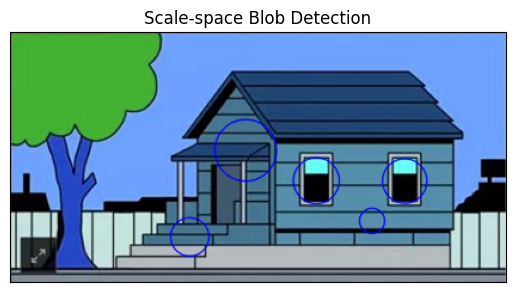

In [ ]:
# Thiết lập tham số cho blob detector
params = cv2.SimpleBlobDetector_Params()

params.filterByArea = True
params.minArea = 50

params.filterByCircularity = False
params.filterByConvexity = False
params.filterByInertia = False

# Tạo blob detector
detector = cv2.SimpleBlobDetector_create(params)

# Phát hiện blob
keypoints = detector.detect(img)

# Vẽ blob lên ảnh
img_blob = cv2.drawKeypoints(img, keypoints, np.array([]),
                             (0,0,255),
                             cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

# Hiển thị ảnh
plt.imshow(img_blob, cmap='gray')
plt.title("Scale-space Blob Detection")
plt.xticks([])
plt.yticks([])
plt.show()

**7. Thực hành với Bag-of-words detection**

Bag of Words Histogram:
[0.00234742 0.00234742 0.00234742 0.00469484 0.11267606 0.08685446
 0.09389671 0.11267606 0.0657277  0.04694836 0.00234742 0.01877934
 0.01643192 0.0657277  0.07511737 0.03286385 0.06103286 0.04694836
 0.05399061 0.09624413]


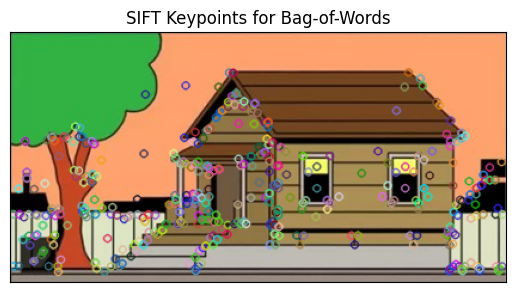

In [ ]:
# 1. Trích xuất đặc trưng SIFT
sift = cv2.SIFT_create()
keypoints, descriptors = sift.detectAndCompute(gray, None)

# 2. Tạo bộ gom cụm KMeans
k = 20
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)

ret, label, center = cv2.kmeans(descriptors.astype(np.float32),
                                k,
                                None,
                                criteria,
                                10,
                                cv2.KMEANS_RANDOM_CENTERS)

# 3. Tạo histogram Bag-of-Words
hist = np.bincount(label.flatten(), minlength=k)

# Chuẩn hóa histogram
hist = hist / np.sum(hist)

print("Bag of Words Histogram:")
print(hist)

# Hiển thị keypoints
img_kp = cv2.drawKeypoints(img, keypoints, None)

plt.imshow(img_kp[:,:,::-1])
plt.title("SIFT Keypoints for Bag-of-Words")
plt.xticks([])
plt.yticks([])
plt.show()

**8. Ghép ảnh Image Panoramas**

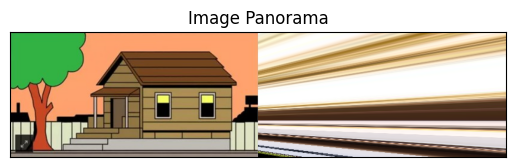

In [27]:
# Đọc ảnh
img1 = cv2.imread('example.jpg')
img2 = cv2.imread('example2.jpg')

# Chuyển sang grayscale
gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

# Sử dụng ORB để tìm keypoints
orb = cv2.ORB_create()

kp1, des1 = orb.detectAndCompute(gray1, None)
kp2, des2 = orb.detectAndCompute(gray2, None)

# Matcher
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
matches = bf.match(des1, des2)

# Sắp xếp match theo độ chính xác
matches = sorted(matches, key=lambda x: x.distance)

# Lấy các điểm tương ứng
src_pts = np.float32([kp1[m.queryIdx].pt for m in matches]).reshape(-1,1,2)
dst_pts = np.float32([kp2[m.trainIdx].pt for m in matches]).reshape(-1,1,2)

# Tính homography
H, mask = cv2.findHomography(dst_pts, src_pts, cv2.RANSAC, 5.0)

# Warp ảnh thứ 2
height, width = img1.shape[:2]
result = cv2.warpPerspective(img2, H, (width*2, height))

# Ghép ảnh
result[0:height, 0:width] = img1

# Hiển thị kết quả
plt.imshow(result[:,:,::-1])
plt.title("Image Panorama")
plt.xticks([])
plt.yticks([])
plt.show()

**9. Ghép ảnh Automatic mosaicing**

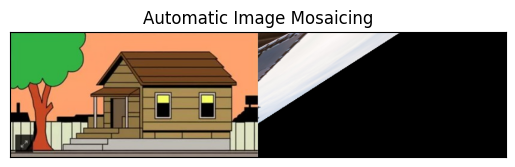

In [30]:
# Đọc hai ảnh cần ghép
img1 = cv2.imread('example.jpg')
img2 = cv2.imread('example2.jpg')

# Chuyển sang grayscale
gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

# Phát hiện đặc trưng SIFT
sift = cv2.SIFT_create()
kp1, des1 = sift.detectAndCompute(gray1, None)
kp2, des2 = sift.detectAndCompute(gray2, None)

# So khớp đặc trưng
bf = cv2.BFMatcher()
matches = bf.knnMatch(des1, des2, k=2)

# Lowe's ratio test
good = []
for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good.append(m)

# Lấy các điểm tương ứng
src_pts = np.float32([kp1[m.queryIdx].pt for m in good]).reshape(-1,1,2)
dst_pts = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1,1,2)

# Tính homography
H, mask = cv2.findHomography(dst_pts, src_pts, cv2.RANSAC, 5.0)

# Warp ảnh thứ hai
h1, w1 = img1.shape[:2]
result = cv2.warpPerspective(img2, H, (w1*2, h1))

# Ghép ảnh
result[0:h1, 0:w1] = img1

# Hiển thị kết quả
plt.imshow(result[:,:,::-1])
plt.title("Automatic Image Mosaicing")
plt.xticks([])
plt.yticks([])
plt.show()

**10. Sử dụng Wide base-line stereo**

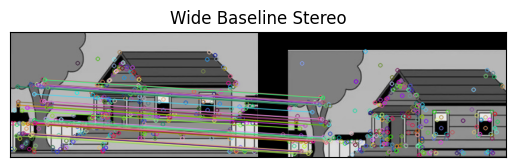

In [37]:
# Đọc ảnh gốc
img1 = cv2.imread('example.jpg',0)

# Tạo ảnh thứ hai bằng phép biến đổi affine
rows, cols = img1.shape
M = np.float32([[1, 0, 50], [0, 1, 30]])  # dịch chuyển ảnh
img2 = cv2.warpAffine(img1, M, (cols, rows))

# SIFT detector
sift = cv2.SIFT_create()

# Tìm keypoints và descriptors
kp1, des1 = sift.detectAndCompute(img1, None)
kp2, des2 = sift.detectAndCompute(img2, None)

# Matcher
bf = cv2.BFMatcher()
matches = bf.knnMatch(des1, des2, k=2)

# Lowe ratio test
good = []
for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good.append(m)

# Vẽ các điểm match
img_match = cv2.drawMatches(img1, kp1, img2, kp2, good[:50], None)

plt.imshow(img_match[:,:,::-1])
plt.title("Wide Baseline Stereo")
plt.xticks([])
plt.yticks([])
plt.show()

**11. CBIR (content-based image retrieval)**

In [40]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Danh sách ảnh trong database
images = ['example.jpg','example2.jpg','example3.jpg','example4.jpg']

# Ảnh truy vấn
query = cv2.imread('example.jpg')

# Tính histogram cho ảnh query
query_hist = cv2.calcHist([query],[0,1,2],None,[8,8,8],[0,256,0,256,0,256])
query_hist = cv2.normalize(query_hist,query_hist).flatten()

results = []

for img_path in images:

    img = cv2.imread(img_path)

    hist = cv2.calcHist([img],[0,1,2],None,[8,8,8],[0,256,0,256,0,256])
    hist = cv2.normalize(hist,hist).flatten()

    # So sánh histogram
    score = cv2.compareHist(query_hist, hist, cv2.HISTCMP_CORREL)

    results.append((score,img_path))

# Sắp xếp kết quả
results = sorted(results, reverse=True)

print("CBIR results:")
for score,path in results:
    print(path,score)

CBIR results:
example.jpg 1.0
example4.jpg 0.11462490265758699
example3.jpg 0.11152806052455239
example2.jpg 0.053898495770761216


**12. Bag-of-word with SIFT + Histogram**

In [41]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
from sklearn.cluster import KMeans

# Danh sách ảnh database
image_paths = ['example.jpg','example2.jpg','example3.jpg','example4.jpg']

# Khởi tạo SIFT
sift = cv2.SIFT_create()

descriptor_list = []

# 1. Trích xuất SIFT descriptors
for path in image_paths:
    img = cv2.imread(path,0)
    kp, des = sift.detectAndCompute(img,None)
    
    if des is not None:
        descriptor_list.extend(des)

descriptor_list = np.array(descriptor_list)

# 2. K-means clustering để tạo visual words
k = 40
kmeans = KMeans(n_clusters=k)
kmeans.fit(descriptor_list)

# 3. Tạo histogram cho từng ảnh
histograms = []

for path in image_paths:
    
    img = cv2.imread(path,0)
    kp, des = sift.detectAndCompute(img,None)
    
    hist = np.zeros(k)
    
    if des is not None:
        labels = kmeans.predict(des)
        
        for l in labels:
            hist[l] += 1
    
    histograms.append(hist)

histograms = np.array(histograms)

print("Histogram representation of images:")
print(histograms)

Histogram representation of images:
[[  3.  12.  10.  31.   7.   8.   8.   0.   1.  14.   6.   8.   6.   3.
    0.   3.  25.  16.  10.  11.   3.   6.   4.   2.  18.  15.  19.  46.
   45.  10.   3.   1.  10.   8.   4.  30.   5.   0.   4.  11.]
 [246. 307. 322. 318. 280. 157. 359. 371. 305. 311. 334. 304. 300. 268.
  351. 315. 409. 307. 355. 277.  99. 287. 343. 273. 353. 264. 300. 148.
  211. 381. 285. 350. 356. 302. 269. 357. 274. 282. 303. 386.]
 [811. 744. 657. 601. 769. 623. 754. 663. 905. 629. 765. 620. 678. 671.
  662. 737. 747. 949. 476. 647. 551. 811. 785. 714. 708. 701. 596. 638.
  518. 828. 630. 864. 786. 715. 810. 628. 756. 784. 751. 725.]
 [443. 551. 336. 433. 471. 649. 441. 364. 417. 368. 384. 423. 422. 627.
  480. 497. 390. 695. 362. 509. 378. 501. 490. 464. 266. 453. 343. 249.
  421. 475. 369. 496. 477. 461. 512. 383. 378. 311. 470. 401.]]
